# Customer Churn Prediction
## Data Science Mini Project

Author: Adil Shaikh  
Model Used: Decision Tree  
Tools: Python, Pandas, Seaborn, Scikit-learn

## Problem Understanding

The objective of this project is to predict customer churn in a telecom company.
Customer churn refers to when a customer stops using the company's services.

In today’s competitive market, retaining customers is very important for business growth.
This project helps in identifying customers who are likely to leave so that the company can take necessary actions to retain them and reduce customer loss.

Important Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Understanding

The dataset contains information about telecom customers such as tenure, monthly charges, contract type, and services used.

Each row represents a customer and their service details. The target variable is "Churn", which indicates whether a customer has left the service (Yes/No).

The dataset consists of multiple features that help in understanding customer behavior and identifying patterns related to churn.

Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Dataset info

In [ ]:

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Data Cleaning & Preprocessing

The dataset was checked for missing values and necessary preprocessing steps were performed.

The "Churn" column was converted into numerical format (Yes = 1, No = 0).
All categorical columns were encoded into numerical values using label encoding so that the machine learning model can process them.

These steps ensured that the dataset was clean, consistent, and ready for model training.

Cleaning Code

In [ ]:
# Convert Churn column
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Encode all categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

## Exploratory Data Analysis

EDA was performed to understand patterns and relationships between different features and customer churn.

From the analysis, it was observed that customers with shorter tenure are more likely to churn.
Also, customers with higher monthly charges tend to leave the service more frequently.

This indicates that new customers and high-paying customers are more likely to discontinue the service if they are not satisfied.

The visualizations helped in identifying important factors that influence customer churn.

EDA Graphs

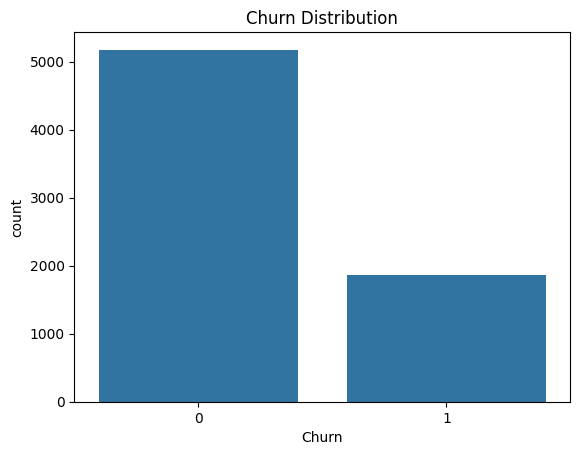

In [ ]:
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


This graph shows the distribution of customers who have churned and those who have not.

It can be observed that the number of customers who did not churn is higher than those who churned.
This means most customers are still using the service.

The graph also indicates a slight class imbalance in the dataset.

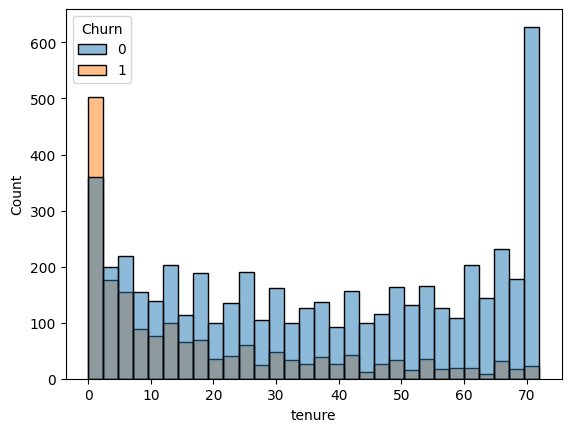

In [ ]:


# Tenure vs churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.show()



This graph shows the relationship between customer tenure and churn.

It can be observed that customers with lower tenure (new customers) have a higher tendency to churn.
As tenure increases, the number of churned customers decreases.

This indicates that long-term customers are more likely to stay with the company.

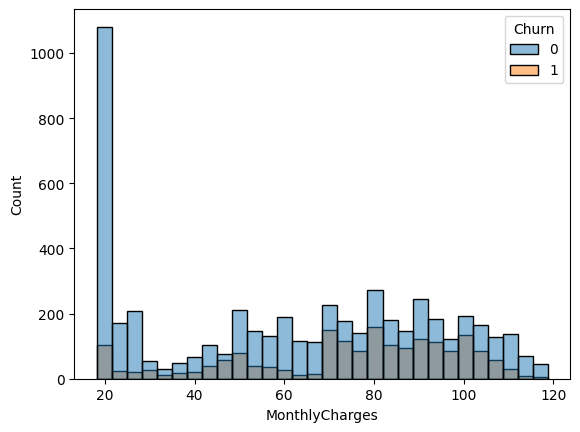

In [ ]:
# Monthly Charges vs churn
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30)
plt.show()

This graph shows the relationship between monthly charges and customer churn.

It can be observed that customers with higher monthly charges are more likely to churn compared to those with lower charges.

This suggests that pricing may play an important role in customer retention.

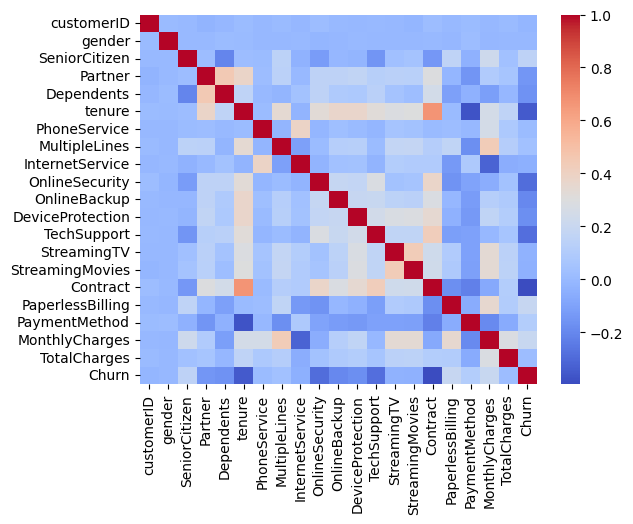

In [ ]:

# Correlation heatmap
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

The heatmap shows the correlation between different features in the dataset.

It helps in understanding how strongly different variables are related to each other.
Some features show a positive or negative relationship with churn.

This visualization helps in identifying important features that may influence customer churn.

## Model Implementation

A Decision Tree classifier was used to predict customer churn.

The dataset was divided into training and testing sets. The model was trained using the training data and tested on unseen data.

Hyperparameter tuning was applied by limiting the depth of the Decision Tree to improve model performance.

Decision Tree was chosen because it is easy to understand, interpretable, and works well for classification problems.

Model Code

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Prediction

In [ ]:
pred = model.predict(X_test)

## Model Evaluation

The model was evaluated using accuracy score and confusion matrix.

The accuracy score shows how well the model performs on test data. The confusion matrix provides detailed information about correct and incorrect predictions.

The model achieved an accuracy of approximately 79%, which indicates that it performs well in predicting customer churn.

Evaluation Code

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, pred)
print("Model Accuracy:", accuracy)

cm = confusion_matrix(y_test, pred)
print(cm)

Model Accuracy: 0.794889992902768
[[884 152]
 [137 236]]


Confusion Matrix Graph

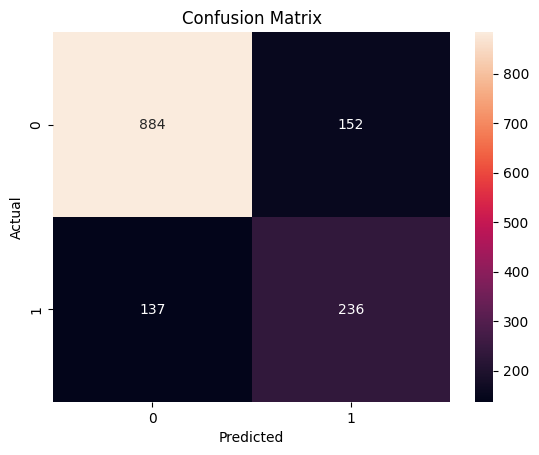

In [ ]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows the performance of the classification model.

It displays the number of correct and incorrect predictions made by the model.
The diagonal values represent correct predictions, while the off-diagonal values represent errors.

This helps in understanding how well the model is performing in predicting churn and non-churn cases.

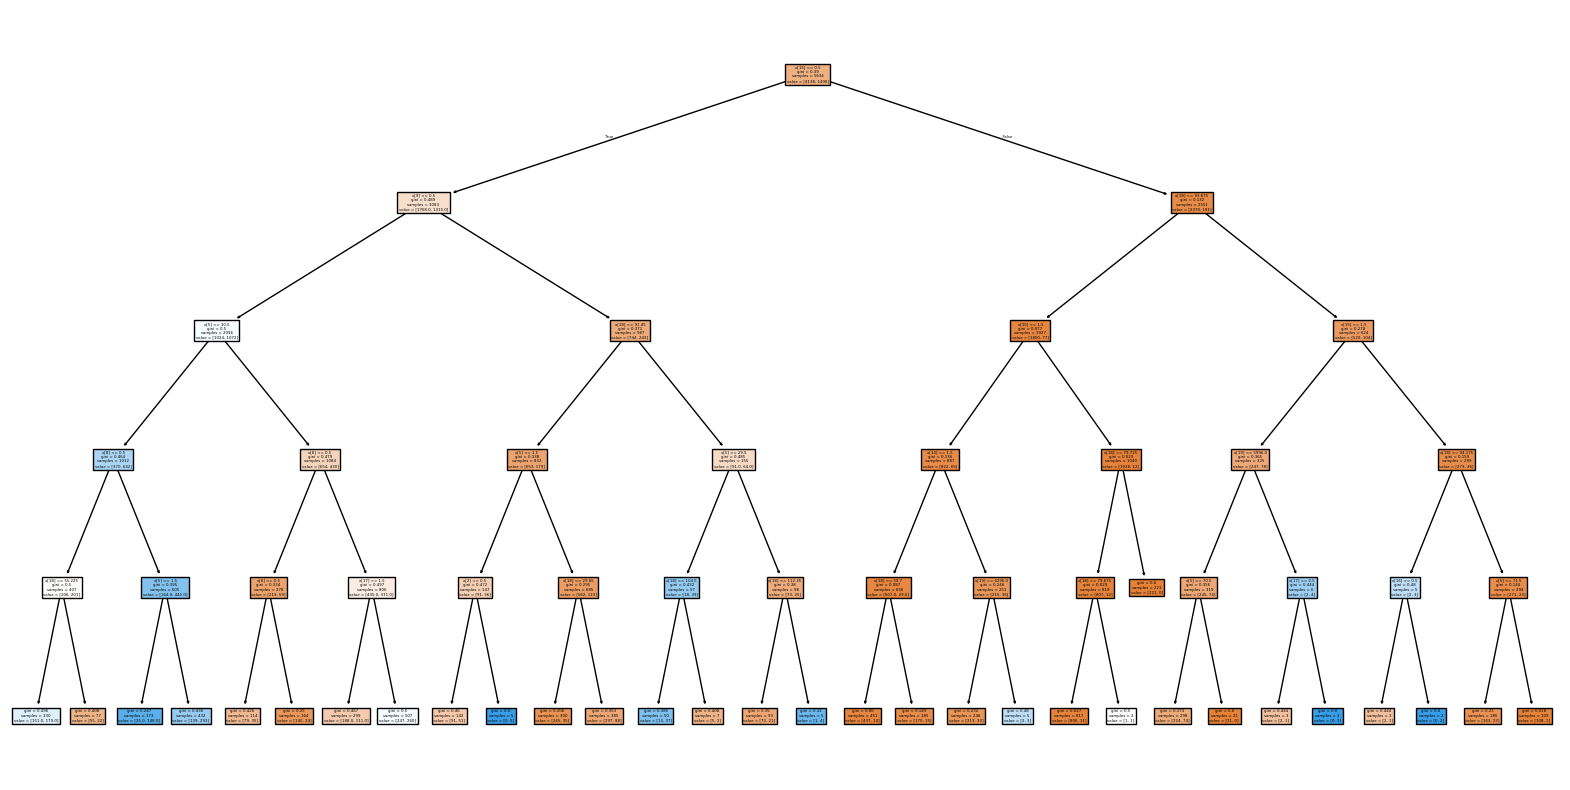

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model, filled=True)
plt.show()

## Visualization & Interpretation

The visualizations show that customers with shorter tenure and higher monthly charges are more likely to churn.

The confusion matrix indicates that the model correctly predicts most of the churn and non-churn cases, although some misclassifications are present.

Overall, the model provides a good understanding of customer behavior and churn patterns.

## Conclusion

The Decision Tree model was successfully used to predict customer churn.

The analysis shows that factors such as tenure, monthly charges, and service usage play an important role in determining whether a customer will leave.

These insights can help telecom companies take proactive steps to retain customers, improve services, and reduce churn.